# Machine Learning Final Assessment: Ransomware Vulnerability Prediction


1. Problem Statement
Security Operations Center (SOC) teams face thousands of newly disclosed software vulnerabilities each year, creating a critical patch-prioritization bottleneck. Organizations cannot remediate all security flaws immediately and need automated systems to identify high-risk vulnerabilities.


The primary objective of this project is to build an automated machine learning classifier that predicts whether a software vulnerability (CVE) is weaponized and actively exploited in ransomware campaigns. By identifying structural patterns across software vendors, product types, and weakness categories, security teams can proactively prioritize critical security patches before active weaponization occurs.

2. Research Question
 How do feature scaling techniques impact the predictive performance (Accuracy, Precision, Recall, F1-Score) of standard machine learning algorithms (Logistic Regression, Decision Tree, Support Vector Machine, Multi-Layer Perceptron) compared to ensemble learning (Random Forest) when classifying ransomware-weaponized software vulnerabilities?

 


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs('../reports/figures', exist_ok=True)

In [3]:


# 1. Load Raw Dataset
df = pd.read_csv('../dataset/initial/2_cve_vulnerabilities.csv')

# 2. Dataset Overview
print("=== Dataset Overview ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")

print("=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Overview ===
Total Rows: 1585
Total Columns: 10

=== Missing Values ===
cveID                         0
vendorProject                 0
product                       0
vulnerabilityName             0
dateAdded                     0
shortDescription              0
requiredAction                0
dueDate                       0
knownRansomwareCampaignUse    0
cwes                          0
dtype: int64


/tmp/ipykernel_8224/3675303452.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='knownRansomwareCampaignUse', data=df, palette='viridis')


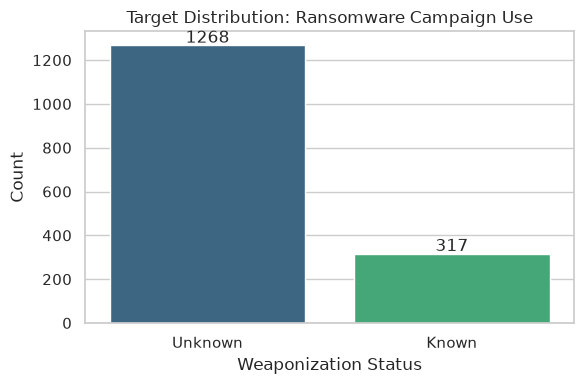

In [4]:
# 3. Chart 1: Target Class Imbalance Plot

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='knownRansomwareCampaignUse', data=df, palette='viridis')
plt.title('Target Distribution: Ransomware Campaign Use')
plt.xlabel('Weaponization Status')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('../reports/figures/eda_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



/tmp/ipykernel_6537/1345905137.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vendors.values, y=top_vendors.index, palette='mako')


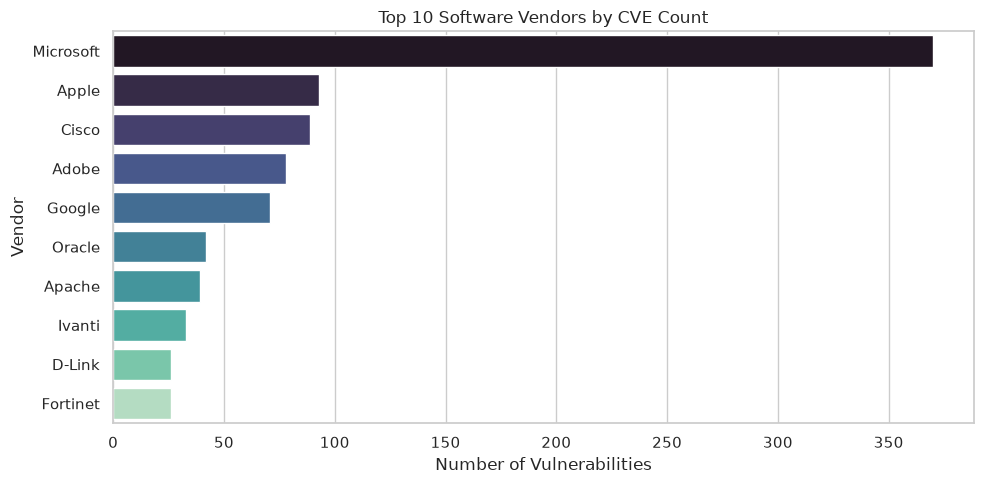

In [14]:
# 4. Chart 2: Top 10 Software Vendors
plt.figure(figsize=(10, 5))
top_vendors = df['vendorProject'].value_counts().head(10)
sns.barplot(x=top_vendors.values, y=top_vendors.index, palette='mako')
plt.title('Top 10 Software Vendors by CVE Count')
plt.xlabel('Number of Vulnerabilities')
plt.ylabel('Vendor')
plt.tight_layout()
plt.savefig('../reports/figures/eda_top_vendors.png', dpi=300, bbox_inches='tight')
plt.show()



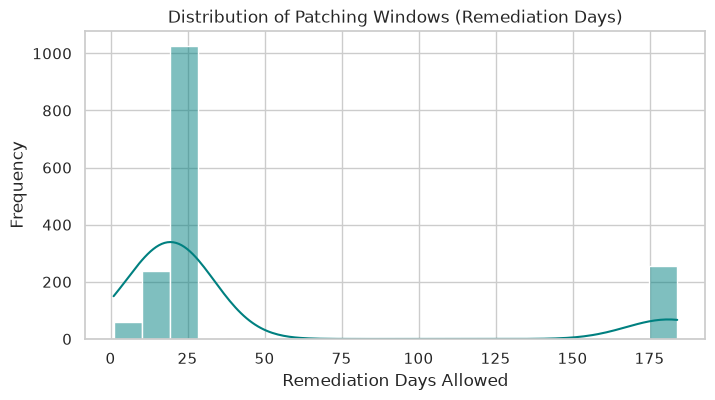

/tmp/ipykernel_8224/231942418.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cwes.values, y=top_cwes.index, palette='viridis')


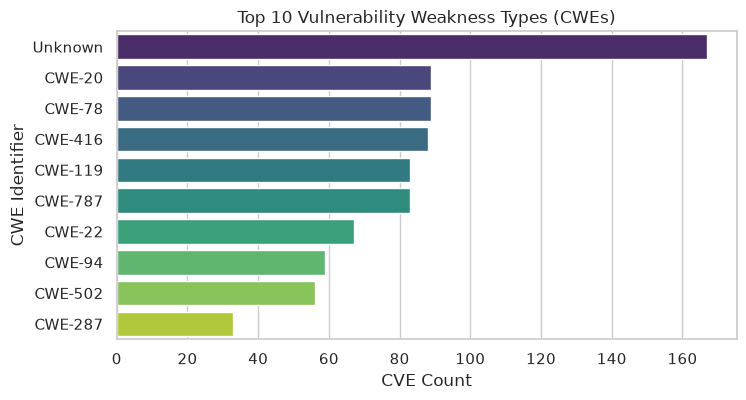

In [6]:
df_temp = df.copy()
df_temp['dateAdded'] = pd.to_datetime(df_temp['dateAdded'])
df_temp['dueDate'] = pd.to_datetime(df_temp['dueDate'])
df_temp['remediation_days'] = (df_temp['dueDate'] - df_temp['dateAdded']).dt.days

plt.figure(figsize=(8, 4))
sns.histplot(df_temp['remediation_days'], bins=20, kde=True, color='teal')
plt.title('Distribution of Patching Windows (Remediation Days)')
plt.xlabel('Remediation Days Allowed')
plt.ylabel('Frequency')
plt.savefig('../reports/figures/eda_remediation_days.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Top Common Weakness Enumerations (CWEs)
plt.figure(figsize=(8, 4))
top_cwes = df['cwes'].value_counts().head(10)
sns.barplot(x=top_cwes.values, y=top_cwes.index, palette='viridis')
plt.title('Top 10 Vulnerability Weakness Types (CWEs)')
plt.xlabel('CVE Count')
plt.ylabel('CWE Identifier')
plt.savefig('../reports/figures/eda_top_cwes.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_6537/2814014003.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='knownRansomwareCampaignUse', y='remediation_days', data=df, palette='Set2')


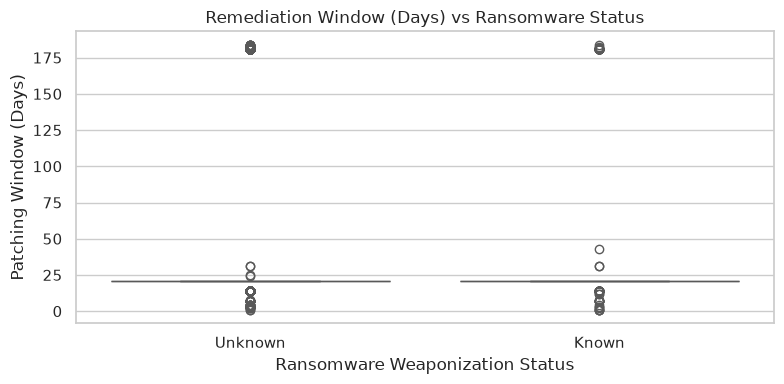

In [7]:
# 5. Chart 3: Remediation Days Feature Engineering & Distribution

df['dateAdded'] = pd.to_datetime(df['dateAdded'])
df['dueDate'] = pd.to_datetime(df['dueDate'])
df['remediation_days'] = (df['dueDate'] - df['dateAdded']).dt.days

plt.figure(figsize=(8, 4))
sns.boxplot(x='knownRansomwareCampaignUse', y='remediation_days', data=df, palette='Set2')
plt.title('Remediation Window (Days) vs Ransomware Status')
plt.xlabel('Ransomware Weaponization Status')
plt.ylabel('Patching Window (Days)')
plt.tight_layout()
plt.show()

 Key EDA Insights & Observations

1. Target Class Imbalance: The target variable shows an 80% (`Unknown`: 1,268) to 20% (`Known`: 317) imbalance. Model evaluation must rely on Precision, Recall, and F1-Score rather than plain Accuracy.
2. Vendor Concentration: Vulnerabilities are heavily concentrated among top enterprise vendors (Microsoft, Apple, Cisco, Adobe, Google).
3. Remediation Window Feature: The median patch window across both categories is 21 days, meaning patch timeframe alone is not linearly separable.